# Exploratory Data Analysis — What Predicts Campaign Response?

Bivariate checks on the cleaned dataset (`CP_data_cleaning.ipynb` output): response rates against demographics, engagement,
and CRM history — with significance tests.
Output feeds into `cp_modeling.ipynb`.

## Setup

In [41]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency

In [42]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

data = pd.read_csv(config['data']['clean']['file1'], quotechar='"', sep=";")
data.shape

(2212, 24)

## Correlation overview

In [43]:
data.select_dtypes('number').corr()

,year_birth,income,recency,wines,fruits,meat,fish,sweets,gold,deals,...,catalogue,store,webvisits,complain,response,age,num_children,customer_tenure_in_days,total_spend,num_camp_success
year_birth,1.000000,-0.199977,-0.015694,-0.164615,-0.013447,-0.033622,-0.041154,-0.021516,-0.059779,-0.066156,...,-0.125856,-0.138998,0.120282,-0.004602,0.020937,-1.000000,-0.092676,0.014216,-0.115901,-0.001878
income,-0.199977,1.000000,0.007965,0.688209,0.507354,0.692279,0.520040,0.523599,0.388299,-0.108207,...,0.696589,0.631424,-0.650257,-0.027900,0.161387,0.199977,-0.343529,-0.023760,0.792740,0.365986
recency,-0.015694,0.007965,1.000000,0.015981,-0.005257,0.022914,0.000788,0.025244,0.018148,0.002591,...,0.024197,-0.000460,-0.018965,0.005713,-0.200114,0.015694,0.018062,0.025681,0.020479,-0.013471
wines,-0.164615,0.688209,0.015981,1.000000,0.385844,0.568081,0.396915,0.389583,0.391461,0.009117,...,0.634237,0.640219,-0.321616,-0.036420,0.246320,0.164615,-0.353356,0.167852,0.892996,0.510349
fruits,-0.013447,0.507354,-0.005257,0.385844,1.000000,0.546740,0.593038,0.571474,0.393459,-0.134191,...,0.485611,0.459875,-0.417741,-0.002956,0.123007,0.013447,-0.395161,0.068137,0.612129,0.155811
meat,-0.033622,0.692279,0.022914,0.568081,0.546740,1.000000,0.572986,0.534624,0.357556,-0.121128,...,0.733787,0.486349,-0.539194,-0.021017,0.237966,0.033622,-0.504176,0.089462,0.845543,0.306383
fish,-0.041154,0.520040,0.000788,0.396915,0.593038,0.572986,1.000000,0.583484,0.426299,-0.143147,...,0.532241,0.457885,-0.446151,-0.019098,0.108135,0.041154,-0.427482,0.081700,0.641884,0.175376
sweets,-0.021516,0.523599,0.025244,0.389583,0.571474,0.534624,0.583484,1.000000,0.356754,-0.121395,...,0.494623,0.455150,-0.422289,-0.020569,0.116059,0.021516,-0.389152,0.080727,0.606652,0.200861
gold,-0.059779,0.388299,0.018148,0.391461,0.393459,0.357556,0.426299,0.356754,1.000000,0.053047,...,0.441656,0.390693,-0.245973,-0.030166,0.141096,0.059779,-0.267776,0.161115,0.527101,0.195504
deals,-0.066156,-0.108207,0.002591,0.009117,-0.134191,-0.121128,-0.143147,-0.121395,0.053047,1.000000,...,-0.012015,0.065635,0.345623,0.003744,0.003226,0.066156,0.436072,0.217948,-0.065571,-0.125615


## Age vs. response

`age` was derived from birth year during cleaning. 

In [44]:
data.groupby('age')['response'].mean()

age
18    0.500000
19    0.200000
20    0.333333
21    0.400000
22    0.076923
23    0.266667
24    0.222222
25    0.034483
26    0.068966
27    0.222222
28    0.219512
29    0.125000
30    0.289474
31    0.268293
32    0.295455
33    0.131579
34    0.128205
35    0.113208
36    0.039474
37    0.215686
38    0.089888
39    0.132530
40    0.159420
41    0.152778
42    0.179487
43    0.162791
44    0.213333
45    0.142857
46    0.117647
47    0.136364
48    0.140000
49    0.081081
50    0.121951
51    0.136364
52    0.113636
53    0.228571
54    0.081633
55    0.120000
56    0.096154
57    0.195122
58    0.145455
59    0.166667
60    0.142857
61    0.200000
62    0.115385
63    0.023810
64    0.103448
65    0.366667
66    0.095238
67    0.250000
68    0.187500
69    0.250000
70    0.142857
71    0.333333
73    0.000000
74    0.000000
Name: response, dtype: float64

In [45]:
conv_success = data[data['response'] == 1].age
conv_failure = data[data['response'] == 0].age
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided")
print(f"t = {t_stat:.4f}, p = {p_value:.4e}")

t = -0.9425, p = 3.4643e-01


## Age vs. income

In [46]:
data[['age', 'income']].corr()

,age,income
age,1.000000,0.199977
income,0.199977,1.000000


No meaningful correlation between age and income in this dataset.

## Income vs. response

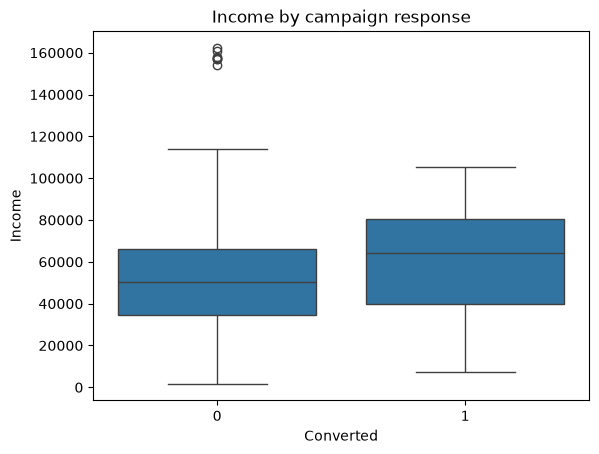

In [73]:
sns.boxplot(data=data, x='response', y='income')
plt.title("Income by campaign response")
plt.ylabel("Income")
plt.xlabel("Converted")
plt.savefig('../figures/cpa-income-response.png', transparent=True, dpi=300)
plt.show()

In [48]:
conv_success = data[data['response'] == 1].income
conv_failure = data[data['response'] == 0].income
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided")
print(f"t = {t_stat:.4f}, p = {p_value:.4e}")

t = 7.1457, p = 3.8285e-12


Responders have significantly higher income than non-responders (Welch's t-test, unequal variances assumed since group sizes and spreads differ).

## Education vs. response

In [49]:
data.groupby('education')['response'].mean()

education
PhD              0.210417
Postgraduate     0.140541
Undergraduate    0.095238
Name: response, dtype: float64

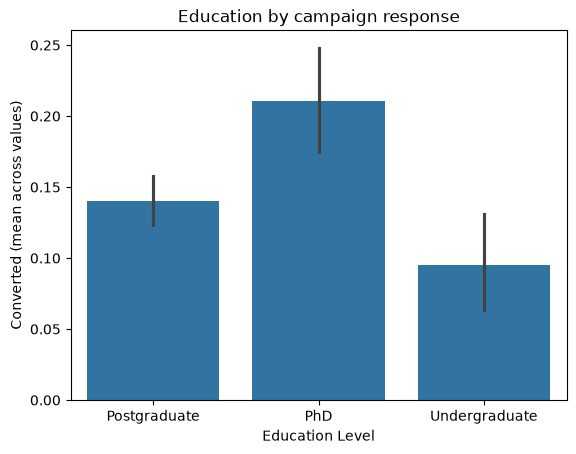

In [74]:
sns.barplot(
    data=data,
    x="education",
    y="response",
    estimator="mean"
)
plt.title("Education by campaign response")
plt.ylabel("Converted (mean across values)")
plt.xlabel("Education Level")
plt.savefig('../figures/cpa-education-response.png', transparent=True, dpi=300)
plt.show()

In [50]:
table = pd.crosstab(data['education'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

chi2 = 20.6412, p = 3.2948e-05


## Marital status vs. response

In [51]:
data.groupby('marital_status')['response'].mean()

marital_status
Partnered    0.110644
Separated    0.214984
Single       0.228512
Name: response, dtype: float64

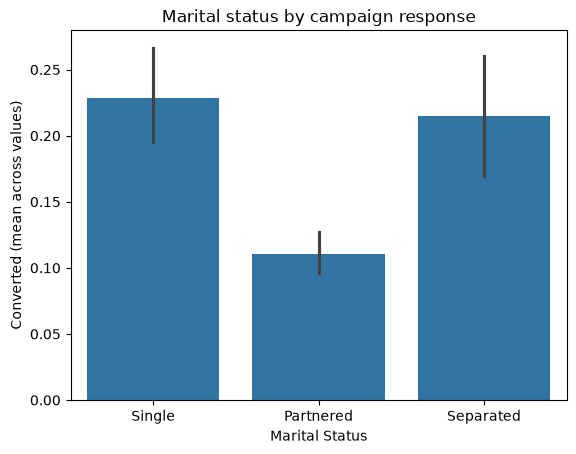

In [75]:
sns.barplot(
    data=data,
    x="marital_status",
    y="response",
    estimator="mean"
)
plt.title("Marital status by campaign response")
plt.ylabel("Converted (mean across values)")
plt.xlabel("Marital Status")
plt.savefig('../figures/cpa-marital_s-response.png', transparent=True, dpi=300)
plt.show()

In [52]:
table = pd.crosstab(data['marital_status'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

chi2 = 50.4211, p = 1.1251e-11


## Complaints vs. response

In [53]:
data.groupby('complain')['response'].mean()

complain
0    0.150547
1    0.150000
Name: response, dtype: float64

## Total spend vs. response

In [82]:
data.groupby('total_spend')['response'].mean()

total_spend
5       0.0
6       0.0
8       0.0
9       0.0
10      0.0
       ... 
2352    0.0
2440    0.0
2486    1.0
2524    1.0
2525    0.5
Name: response, Length: 1047, dtype: float64

In [83]:
table = pd.crosstab(data['total_spend'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

chi2 = 1434.2028, p = 1.1461e-14


## Children vs. response

In [54]:
data.groupby('num_children')['response'].mean()

num_children
0    0.265823
1    0.104129
2    0.112981
3    0.040000
Name: response, dtype: float64

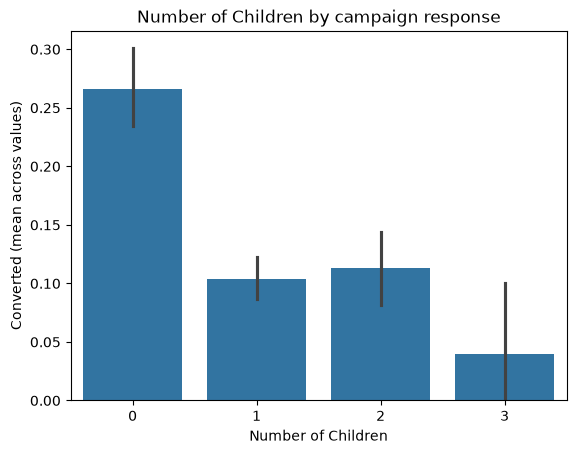

In [76]:
sns.barplot(
    data=data,
    x="num_children",
    y="response",
    estimator="mean"
)
plt.title("Number of Children by campaign response")
plt.ylabel("Converted (mean across values)")
plt.xlabel("Number of Children")
plt.savefig('../figures/cpa-children-response.png', transparent=True, dpi=300)
plt.show()

In [84]:
table = pd.crosstab(data['num_children'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

chi2 = 93.8123, p = 3.3231e-20


In [56]:
# Has_child is boolean (True/False), which ttest_ind treats as 1/0 — same test,
# coarser lens than the exact child count above.
conv_success = data[data['response'] == 1].has_child
conv_failure = data[data['response'] == 0].has_child
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided")
print(f"t = {t_stat:.4f}, p = {p_value:.4e}")

t = -8.8242, p = 2.9167e-17


## Past campaign success vs. response

In [57]:
data.groupby('num_camp_success')['response'].mean()

num_camp_success
0    0.083238
1    0.310559
2    0.518519
3    0.795455
4    0.909091
Name: response, dtype: float64

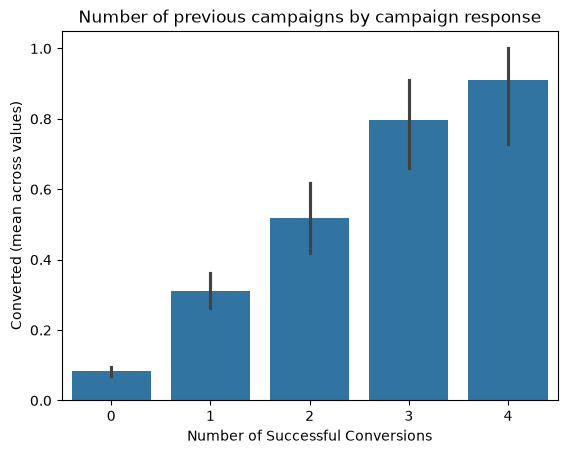

In [77]:
sns.barplot(
    data=data,
    x="num_camp_success",
    y="response",
    estimator="mean"
)
plt.title("Number of previous campaigns by campaign response")
plt.ylabel("Converted (mean across values)")
plt.xlabel("Number of Successful Conversions")
plt.savefig('../figures/cpa-campaigns-response.png', transparent=True, dpi=300)
plt.show()

In [58]:
conv_success = data[data['response'] == 1].num_camp_success
conv_failure = data[data['response'] == 0].num_camp_success
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided")
print(f"t = {t_stat:.4f}, p = {p_value:.4e}")

t = 13.0021, p = 7.5040e-32


In [80]:
data.response.value_counts()/2212*100

response
0    84.94575
1    15.05425
Name: count, dtype: float64

## Export

In [59]:
data.columns

Index(['year_birth', 'education', 'marital_status', 'income', 'recency',
       'wines', 'fruits', 'meat', 'fish', 'sweets', 'gold', 'deals', 'web',
       'catalogue', 'store', 'webvisits', 'complain', 'response', 'age',
       'num_children', 'has_child', 'customer_tenure_in_days', 'total_spend',
       'num_camp_success'],
      dtype='str')

In [81]:
data.select_dtypes("number")

,year_birth,income,recency,wines,fruits,meat,fish,sweets,gold,deals,...,catalogue,store,webvisits,complain,response,age,num_children,customer_tenure_in_days,total_spend,num_camp_success
0,1957,58138.0,58,635,88,546,172,88,88,3,...,10,4,7,0,1,57,0,665,1617,0
1,1954,46344.0,38,11,1,6,2,1,6,2,...,1,2,5,0,0,60,2,115,27,0
2,1965,71613.0,26,426,49,127,111,21,42,1,...,2,10,4,0,0,49,0,314,776,0
3,1984,26646.0,26,11,4,20,10,3,5,2,...,0,4,6,0,0,30,1,141,53,0
4,1981,58293.0,94,173,43,118,46,27,15,5,...,3,6,5,0,0,33,1,163,422,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,1967,61223.0,46,709,43,182,42,118,247,2,...,3,4,5,0,0,47,1,383,1341,0
2208,1946,64014.0,56,406,0,30,0,0,8,7,...,2,5,7,0,0,68,3,21,444,1
2209,1981,56981.0,91,908,48,217,32,12,24,1,...,3,13,6,0,0,33,0,157,1241,1
2210,1956,69245.0,8,428,30,214,80,30,61,2,...,5,10,3,0,0,58,1,158,843,0


In [60]:
data.to_csv("../data/clean/CP_ready_to_model.csv", index=False, encoding="utf-8", sep=";")

## Summary

Age and income are not correlated. Campaign response is higher for higher
income, higher education, and customers who live alone with no children.
Prior campaign success is the strongest signal of all — people who've
responded before are far more likely to respond again, which is the basis
for including `num_camp_success` as a core feature in the modeling stage.